In [1]:
import pandas as pd
import numpy as np
import geopandas as gpd
import matplotlib.pyplot as plt
import seaborn as sns

#from simpledbf import Dbf5
#import openpyxl
from sklearn.preprocessing import StandardScaler, MinMaxScaler

from sklearn.cluster import KMeans

In [2]:
agebs_gdf = gpd.read_file("26/ageb_urb.shp").to_crs("4326").cx[-111.25:-110.75, 28.9:29.3].reset_index()
agebs_gdf.head()

,index,CVEGEO,POB1,POB2,POB2_R,POB3,POB3_R,POB4,POB4_R,POB5,...,POB78,POB78_R,POB79,POB79_R,POB80,POB80_R,POB81,POB81_R,OID,geometry
0,1016,2603000010023,0,-6,-6.0,-6,-6.0,-6,-6.0,-6,...,-6,-6.0,-6,-6.0,-6,-6.0,-6,-6.0,1017,"POLYGON ((-110.99153 29.06045, -110.99091 29.0..."
1,1017,2603000010076,6,-6,-6.0,-6,-6.0,-6,-6.0,-6,...,-6,-6.0,-6,-6.0,-6,-6.0,-6,-6.0,1018,"POLYGON ((-111.03254 29.1459, -111.03275 29.14..."
2,1018,2603000010080,0,0,-8.0,0,-8.0,0,-8.0,0,...,0,-8.0,0,-8.0,0,-8.0,0,-8.0,1019,"POLYGON ((-111.02556 29.16581, -111.02558 29.1..."
3,1019,2603000010095,218,22,10.1,32,14.7,13,6.0,19,...,53,49.1,0,0.0,0,0.0,0,0.0,1020,"POLYGON ((-111.00192 29.16435, -111.00197 29.1..."
4,1020,2603000010108,0,0,-8.0,0,-8.0,0,-8.0,0,...,0,-8.0,0,-8.0,0,-8.0,0,-8.0,1021,"POLYGON ((-110.98598 29.16559, -110.9871 29.16..."


In [3]:
data = pd.read_csv("nominal_data_dengue_2010.csv")
data_by_date = pd.read_csv("data_by_date.csv")
gdf = gpd.GeoDataFrame(
    data_by_date, geometry=gpd.points_from_xy(data["x"], data["y"]), crs="EPSG:4326"
)
gdf["x"] = data["x"]
gdf["y"] = data["y"]
gdf.head()

,I_CUADRO,OBJECTID,Join_Count,TARGET_FID,ID_HILLO,ID_SON,ANYO,FOLIO,SEXO,EDAD,...,y,Unnamed: 69,day,week,month,year,dayofyear,FD,FHD,geometry
0,2010-01-30,1,1,217,231,6261,0,61,hombre,35,...,29.129075,NaN,30,4,1,2010,30,1,0,POINT (-110.95896 29.12907)
1,2010-05-06,3,1,219,233,6425,0,296,hombre,14,...,29.131731,NaN,6,18,5,2010,126,1,0,POINT (-110.96599 29.13173)
2,2010-05-09,2,1,218,232,6424,0,295,mujer,38,...,29.131733,NaN,9,18,5,2010,129,1,0,POINT (-110.96599 29.13173)
3,2010-06-04,4,1,220,234,6497,0,427,mujer,22,...,29.124453,NaN,4,22,6,2010,155,0,1,POINT (-110.97927 29.12445)
4,2010-07-04,6,2,222,236,6581,0,546,hombre,12,...,29.138764,NaN,4,26,7,2010,185,1,0,POINT (-110.96328 29.13876)


<Axes: >

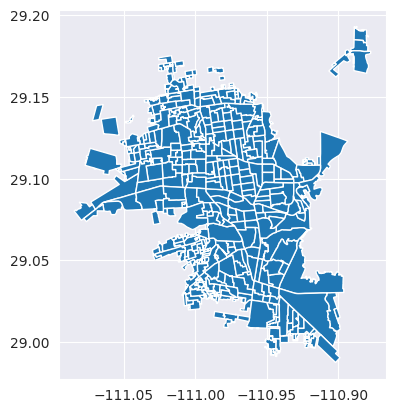

In [9]:
agebs_gdf.plot()

In [11]:
kmeans_df = gdf[["x", "y", "SEXO", "EDAD", "GRADO_MA_1", "DENSI_POB", "week", "FD_FHD"]]
kmeans_df.set_index(np.arange(len(kmeans_df)), inplace=True)

sexo_df = pd.get_dummies(kmeans_df["SEXO"], dtype="int", drop_first=True)
kmeans_df = pd.concat([kmeans_df, sexo_df], axis=1)
kmeans_df.drop("SEXO", axis=1, inplace=True)

fd_fhd_df = pd.get_dummies(kmeans_df["FD_FHD"], dtype="int", drop_first=True)
kmeans_df = pd.concat([kmeans_df, fd_fhd_df], axis=1)
kmeans_df.drop("FD_FHD", axis=1, inplace=True)

kmeans_df.columns = ["x", "y", "edad", "grad_marg", "densi_pob", "semana", "sexo", "FHD"]

kmeans_df.head()

,x,y,edad,grad_marg,densi_pob,semana,sexo,FHD
0,-110.958961,29.129075,35,2,113.109116,4,0,0
1,-110.965989,29.131731,14,1,99.731018,18,0,0
2,-110.965989,29.131733,38,1,99.731018,18,1,0
3,-110.979272,29.124453,22,1,111.530258,22,1,1
4,-110.963284,29.138764,12,3,122.000382,26,0,0


<Axes: >

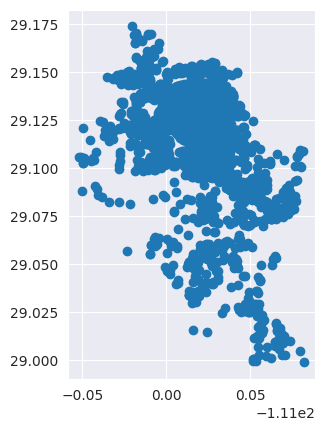

In [12]:
gdf.plot()

In [13]:
standard_scaler = StandardScaler()
min_max_scaler = MinMaxScaler()
standard_scaled_df = pd.DataFrame(standard_scaler.fit_transform(kmeans_df.drop(["sexo", "grad_marg", "semana", "FHD"], axis=1)))
min_max_scaled_df = pd.DataFrame(min_max_scaler.fit_transform(kmeans_df[["grad_marg", "semana"]]))
standard_scaled_df.columns = ["x", "y", "edad", "densi_pob"]
min_max_scaled_df.columns = ["grad_marg", "semana"]

In [14]:
kmeans_df = pd.concat([standard_scaled_df, min_max_scaled_df, kmeans_df["sexo"]], axis=1)
kmeans_df.head()

,x,y,edad,densi_pob,grad_marg,semana,sexo
0,0.862376,0.531840,0.149513,1.184968,0.25,0.000000,0
1,0.543364,0.621615,-0.962434,0.733040,0.00,0.291667,0
2,0.543346,0.621694,0.308363,0.733040,0.00,0.291667,1
3,-0.059562,0.375662,-0.538835,1.131632,0.00,0.375000,1
4,0.666173,0.859333,-1.068333,1.485326,0.50,0.458333,0


In [15]:
kmeans_df.isna().sum()

x            0
y            0
edad         0
densi_pob    0
grad_marg    0
semana       0
sexo         0
dtype: int64

In [16]:
kmeans = KMeans(n_clusters=4).fit(kmeans_df)
kmeans.labels_

array([3, 3, 3, ..., 3, 0, 3], shape=(2728,), dtype=int32)

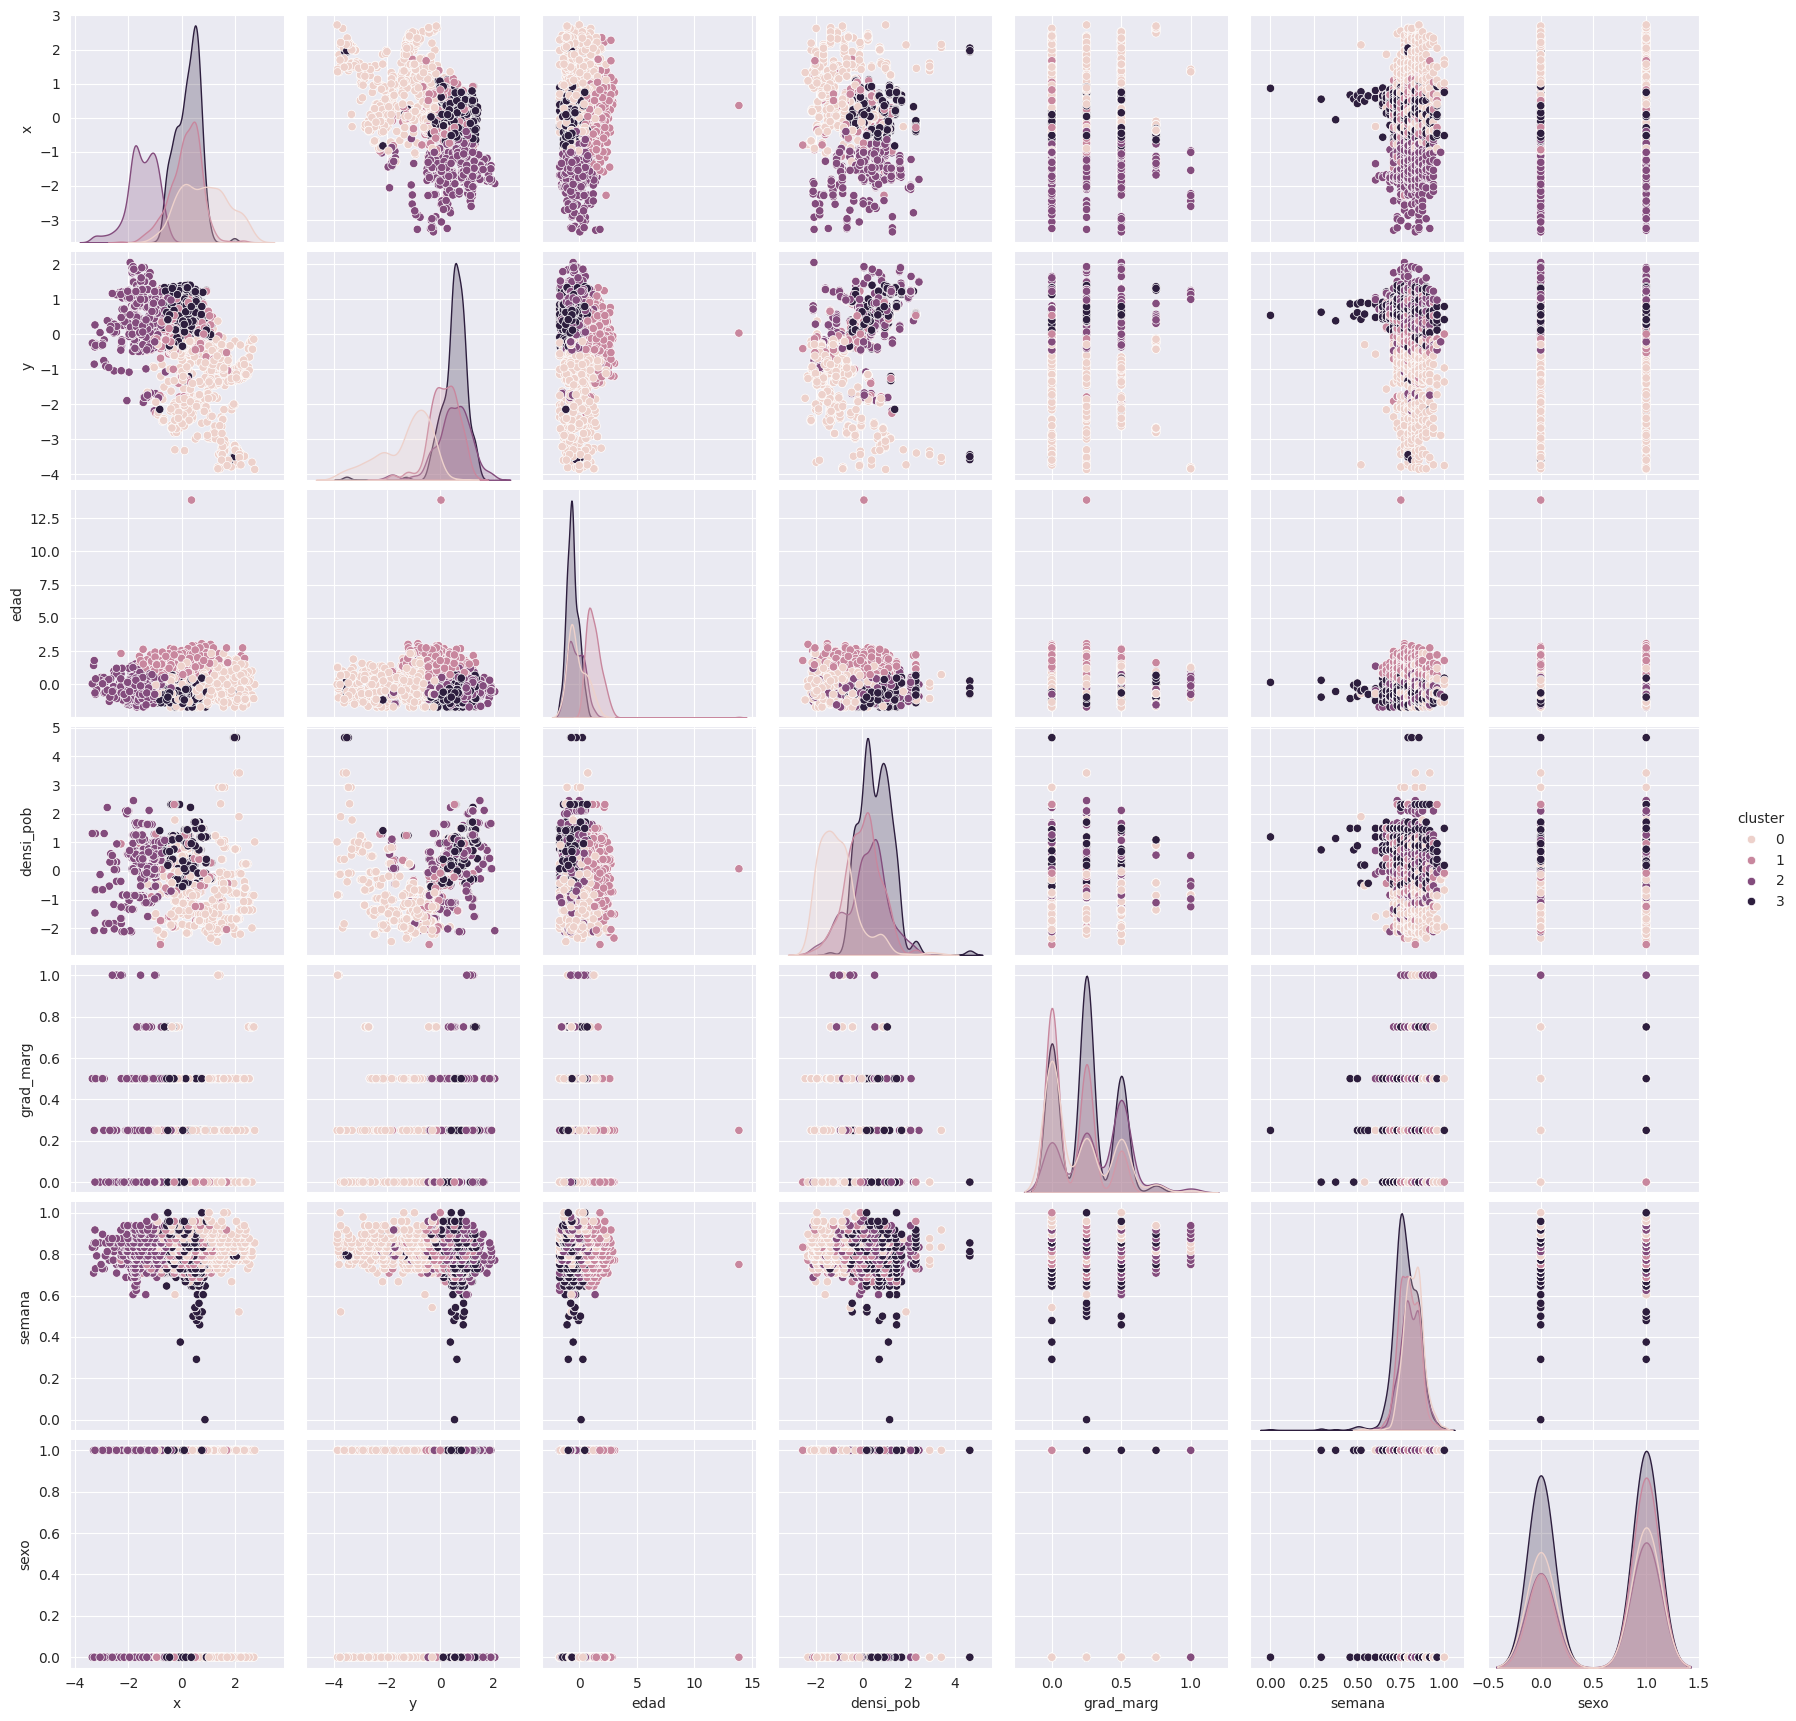

In [17]:
kmeans_df["cluster"] = kmeans.labels_
pairplot_kmeans = sns.pairplot(kmeans_df, hue="cluster")

# Obteniendo Población por AGEBs de cada Cluster

In [18]:
gdf["cluster"] = kmeans.labels_
gdf

,I_CUADRO,OBJECTID,Join_Count,TARGET_FID,ID_HILLO,ID_SON,ANYO,FOLIO,SEXO,EDAD,...,Unnamed: 69,day,week,month,year,dayofyear,FD,FHD,geometry,cluster
0,2010-01-30,1,1,217,231,6261,0,61,hombre,35,...,NaN,30,4,1,2010,30,1,0,POINT (-110.95896 29.12907),3
1,2010-05-06,3,1,219,233,6425,0,296,hombre,14,...,NaN,6,18,5,2010,126,1,0,POINT (-110.96599 29.13173),3
2,2010-05-09,2,1,218,232,6424,0,295,mujer,38,...,NaN,9,18,5,2010,129,1,0,POINT (-110.96599 29.13173),3
3,2010-06-04,4,1,220,234,6497,0,427,mujer,22,...,NaN,4,22,6,2010,155,0,1,POINT (-110.97927 29.12445),3
4,2010-07-04,6,2,222,236,6581,0,546,hombre,12,...,NaN,4,26,7,2010,185,1,0,POINT (-110.96328 29.13876),3
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2723,2010-12-28,2345,2,2562,2688,11089,0,5648,mujer,66,...,NaN,28,52,12,2010,362,1,0,POINT (-110.95999 29.11326),1
2724,2010-12-28,2348,1,2565,2691,11093,0,5652,mujer,7,...,NaN,28,52,12,2010,362,0,1,POINT (-110.94337 29.08464),0
2725,2010-12-31,2352,1,2569,2695,11113,0,5676,mujer,41,...,NaN,31,52,12,2010,365,1,0,POINT (-110.96156 29.13656),3
2726,2010-12-31,2353,1,2570,2696,11114,0,5677,hombre,38,...,NaN,31,52,12,2010,365,1,0,POINT (-110.95555 29.07282),0


In [19]:
gdf_cluster_0 = gdf[gdf["cluster"] == 0]
gdf_cluster_1 = gdf[gdf["cluster"] == 1]
gdf_cluster_2 = gdf[gdf["cluster"] == 2]
gdf_cluster_3 = gdf[gdf["cluster"] == 3]

<Axes: >

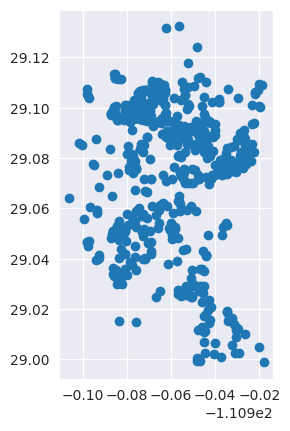

In [20]:
gdf_cluster_0.plot()

In [21]:
gdf.head()

,I_CUADRO,OBJECTID,Join_Count,TARGET_FID,ID_HILLO,ID_SON,ANYO,FOLIO,SEXO,EDAD,...,Unnamed: 69,day,week,month,year,dayofyear,FD,FHD,geometry,cluster
0,2010-01-30,1,1,217,231,6261,0,61,hombre,35,...,NaN,30,4,1,2010,30,1,0,POINT (-110.95896 29.12907),3
1,2010-05-06,3,1,219,233,6425,0,296,hombre,14,...,NaN,6,18,5,2010,126,1,0,POINT (-110.96599 29.13173),3
2,2010-05-09,2,1,218,232,6424,0,295,mujer,38,...,NaN,9,18,5,2010,129,1,0,POINT (-110.96599 29.13173),3
3,2010-06-04,4,1,220,234,6497,0,427,mujer,22,...,NaN,4,22,6,2010,155,0,1,POINT (-110.97927 29.12445),3
4,2010-07-04,6,2,222,236,6581,0,546,hombre,12,...,NaN,4,26,7,2010,185,1,0,POINT (-110.96328 29.13876),3


In [22]:
joined_cluster_0 = gpd.sjoin(agebs_gdf, gdf_cluster_0, how='inner', predicate='contains')
joined_cluster_1 = gpd.sjoin(agebs_gdf, gdf_cluster_1, how='inner', predicate='contains')
joined_cluster_2 = gpd.sjoin(agebs_gdf, gdf_cluster_2, how='inner', predicate='contains')
joined_cluster_3 = gpd.sjoin(agebs_gdf, gdf_cluster_3, how='inner', predicate='contains')

# Get the unique polygon indices that contain at least one point
agebs_with_points_0 = joined_cluster_0.index.unique()
agebs_with_points_1 = joined_cluster_1.index.unique()
agebs_with_points_2 = joined_cluster_2.index.unique()
agebs_with_points_3 = joined_cluster_3.index.unique()

# Filter the original polygon dataframe
agebs_cluster_0 = agebs_gdf.loc[agebs_with_points_0]
agebs_cluster_1 = agebs_gdf.loc[agebs_with_points_1]
agebs_cluster_2 = agebs_gdf.loc[agebs_with_points_2]
agebs_cluster_3 = agebs_gdf.loc[agebs_with_points_3]


Text(0.5, 1.0, 'Cluster 3')

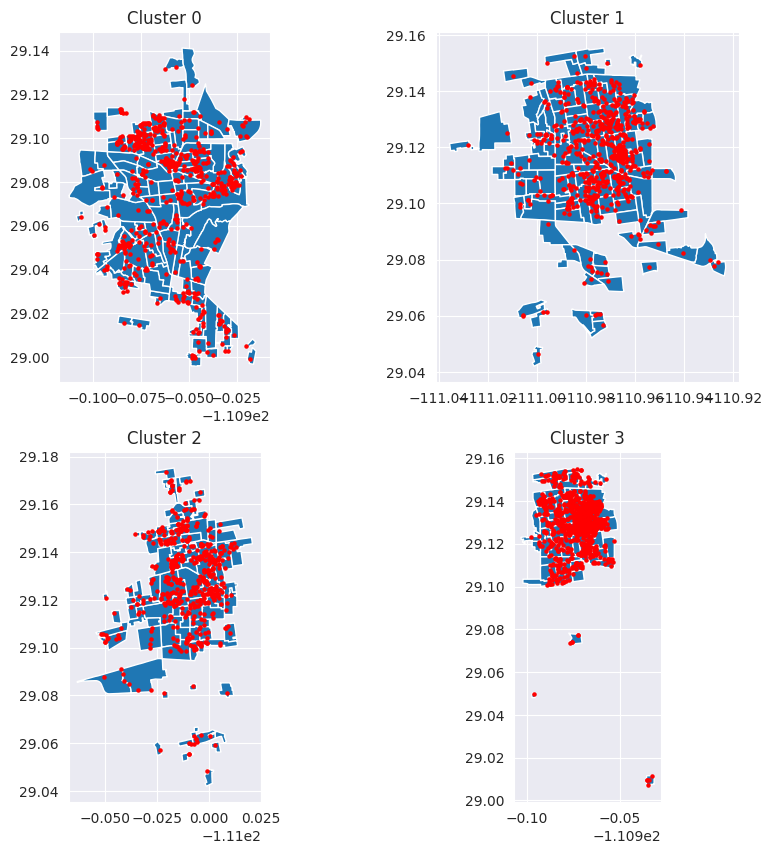

In [23]:
fig, axes = plt.subplots(2,2,figsize=(10,10))
agebs_cluster_0.plot(ax=axes[0,0])
gdf_cluster_0.plot(ax=axes[0,0], color="red", markersize=5)
axes[0,0].set_title("Cluster 0")

agebs_cluster_1.plot(ax=axes[0,1])
gdf_cluster_1.plot(ax=axes[0,1], color="red", markersize=5)
axes[0,1].set_title("Cluster 1")

agebs_cluster_2.plot(ax=axes[1,0])
gdf_cluster_2.plot(ax=axes[1,0], color="red", markersize=5)
axes[1,0].set_title("Cluster 2")

agebs_cluster_3.plot(ax=axes[1,1])
gdf_cluster_3.plot(ax=axes[1,1], color="red", markersize=5)
axes[1,1].set_title("Cluster 3")




In [24]:
pob_total_cluster_0 = agebs_cluster_0["POB1"].sum()
pob_total_cluster_1 = agebs_cluster_1["POB1"].sum()
pob_total_cluster_2 = agebs_cluster_2["POB1"].sum()
pob_total_cluster_3 = agebs_cluster_3["POB1"].sum()
pob_total = pob_total_cluster_0 + pob_total_cluster_1 + pob_total_cluster_2 + pob_total_cluster_3

print(f"Población total de Cluster 0:\t{pob_total_cluster_0}")
print(f"Población total de Cluster 1:\t{pob_total_cluster_1}")
print(f"Población total de Cluster 2:\t{pob_total_cluster_2}")
print(f"Población total de Cluster 3:\t{pob_total_cluster_3}")
print(f"Población total:\t\t\t\t{pob_total}")

Población total de Cluster 0:	282784
Población total de Cluster 1:	288758
Población total de Cluster 2:	235596
Población total de Cluster 3:	182924
Población total:				990062
